In [1]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV ,
    StratifiedKFold
)

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [2]:
df = pd.read_csv(
    "MiningProcess_Flotation_Plant_Database.csv",
    decimal=',' ,nrows=50000
)

df.head()

,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,2017-03-10 01:00:00,55.2,16.98,3019.53,557.434,395.713,10.0664,1.74,249.214,253.235,...,250.884,457.396,432.962,424.954,443.558,502.255,446.370,523.344,66.91,1.31
1,2017-03-10 01:00:00,55.2,16.98,3024.41,563.965,397.383,10.0672,1.74,249.719,250.532,...,248.994,451.891,429.560,432.939,448.086,496.363,445.922,498.075,66.91,1.31
2,2017-03-10 01:00:00,55.2,16.98,3043.46,568.054,399.668,10.0680,1.74,249.741,247.874,...,248.071,451.240,468.927,434.610,449.688,484.411,447.826,458.567,66.91,1.31
3,2017-03-10 01:00:00,55.2,16.98,3047.36,568.665,397.939,10.0689,1.74,249.917,254.487,...,251.147,452.441,458.165,442.865,446.210,471.411,437.690,427.669,66.91,1.31
4,2017-03-10 01:00:00,55.2,16.98,3033.69,558.167,400.254,10.0697,1.74,250.203,252.136,...,248.928,452.441,452.900,450.523,453.670,462.598,443.682,425.679,66.91,1.31


In [3]:
df.columns

Index(['date', '% Iron Feed', '% Silica Feed', 'Starch Flow', 'Amina Flow',
       'Ore Pulp Flow', 'Ore Pulp pH', 'Ore Pulp Density',
       'Flotation Column 01 Air Flow', 'Flotation Column 02 Air Flow',
       'Flotation Column 03 Air Flow', 'Flotation Column 04 Air Flow',
       'Flotation Column 05 Air Flow', 'Flotation Column 06 Air Flow',
       'Flotation Column 07 Air Flow', 'Flotation Column 01 Level',
       'Flotation Column 02 Level', 'Flotation Column 03 Level',
       'Flotation Column 04 Level', 'Flotation Column 05 Level',
       'Flotation Column 06 Level', 'Flotation Column 07 Level',
       '% Iron Concentrate', '% Silica Concentrate'],
      dtype='str')

In [4]:
print(df.shape)


(50000, 24)


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   date                          50000 non-null  str    
 1   % Iron Feed                   50000 non-null  float64
 2   % Silica Feed                 50000 non-null  float64
 3   Starch Flow                   50000 non-null  float64
 4   Amina Flow                    50000 non-null  float64
 5   Ore Pulp Flow                 50000 non-null  float64
 6   Ore Pulp pH                   50000 non-null  float64
 7   Ore Pulp Density              50000 non-null  float64
 8   Flotation Column 01 Air Flow  50000 non-null  float64
 9   Flotation Column 02 Air Flow  50000 non-null  float64
 10  Flotation Column 03 Air Flow  50000 non-null  float64
 11  Flotation Column 04 Air Flow  50000 non-null  float64
 12  Flotation Column 05 Air Flow  50000 non-null  float64
 13  Flotation Co

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
% Iron Feed,50000.0,58.505610,1.972176e+00,54.30000,57.35000,59.09000,59.720000,61.3800
% Silica Feed,50000.0,11.288252,3.138426e+00,8.24000,9.19000,10.10000,12.730000,20.1400
Starch Flow,50000.0,2756.605625,1.189428e+03,0.01323,2086.71750,2660.16000,3616.067500,6250.0000
Amina Flow,50000.0,490.141031,8.709145e+01,241.83000,439.88000,523.52900,555.786000,714.1410
Ore Pulp Flow,50000.0,400.133672,5.641962e+00,376.26000,397.04600,399.98050,403.037000,418.6280
Ore Pulp pH,50000.0,9.614503,3.386668e-01,8.75334,9.38805,9.61787,9.857247,10.7989
Ore Pulp Density,50000.0,1.709751,7.936406e-02,1.51983,1.69479,1.74098,1.760000,1.8531
Flotation Column 01 Air Flow,50000.0,230.745139,2.714637e+01,175.75200,200.07100,249.22300,250.291000,261.2550
Flotation Column 02 Air Flow,50000.0,230.604051,2.735211e+01,175.15600,198.24675,247.91700,250.961000,332.4460
Flotation Column 03 Air Flow,50000.0,231.244113,2.622864e+01,176.46900,200.32800,249.04300,250.488000,286.6770


In [7]:

print("Duplicates :", df.duplicated().sum())


Duplicates : 1


In [8]:
df.drop_duplicates(inplace=True)

In [9]:
print("Missing Values")

print(df.isnull().sum().sum())

Missing Values
0


In [10]:
df.drop('date' , axis=1 , inplace=True)

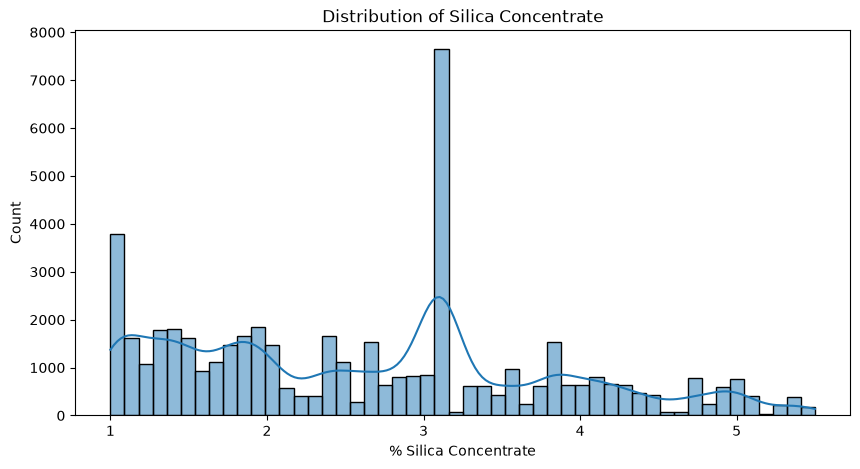

In [11]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['% Silica Concentrate'],
    bins=50,
    kde=True
)

plt.title("Distribution of Silica Concentrate")

plt.show()

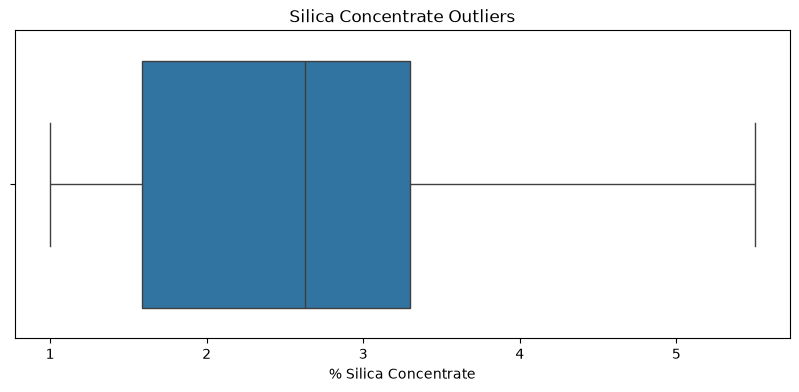

In [12]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=df['% Silica Concentrate']
)

plt.title("Silica Concentrate Outliers")

plt.show()

In [13]:
numeric_df = df.select_dtypes(include='number')

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)

IQR = Q3 - Q1

outliers = ((numeric_df < (Q1 - 1.5 * IQR)) |
            (numeric_df > (Q3 + 1.5 * IQR)))

outlier_percent = (outliers.sum() / len(numeric_df)) * 100

outlier_percent.sort_values(ascending=False)


Flotation Column 06 Air Flow    17.016340
Ore Pulp Density                14.132283
Flotation Column 04 Level        7.188144
Flotation Column 07 Air Flow     6.342127
Ore Pulp Flow                    5.924118
Flotation Column 07 Level        3.930079
Flotation Column 06 Level        2.986060
% Silica Feed                    2.160043
Flotation Column 05 Level        2.090042
Amina Flow                       1.338027
Starch Flow                      0.166003
Ore Pulp pH                      0.040001
Flotation Column 02 Air Flow     0.002000
% Iron Feed                      0.000000
Flotation Column 03 Level        0.000000
% Iron Concentrate               0.000000
Flotation Column 05 Air Flow     0.000000
Flotation Column 02 Level        0.000000
Flotation Column 01 Level        0.000000
Flotation Column 04 Air Flow     0.000000
Flotation Column 03 Air Flow     0.000000
Flotation Column 01 Air Flow     0.000000
% Silica Concentrate             0.000000
dtype: float64

In [14]:
X = df.drop(
    columns=[
        '% Silica Concentrate',
        '% Iron Concentrate'
    ]
)

Y = df['% Silica Concentrate']

print(X.shape)

print(Y.shape)

(49999, 21)
(49999,)


In [15]:
print(X.dtypes)

print("\nObject Columns:")
print(X.select_dtypes(include=['object']).columns)

% Iron Feed                     float64
% Silica Feed                   float64
Starch Flow                     float64
Amina Flow                      float64
Ore Pulp Flow                   float64
Ore Pulp pH                     float64
Ore Pulp Density                float64
Flotation Column 01 Air Flow    float64
Flotation Column 02 Air Flow    float64
Flotation Column 03 Air Flow    float64
Flotation Column 04 Air Flow    float64
Flotation Column 05 Air Flow    float64
Flotation Column 06 Air Flow    float64
Flotation Column 07 Air Flow    float64
Flotation Column 01 Level       float64
Flotation Column 02 Level       float64
Flotation Column 03 Level       float64
Flotation Column 04 Level       float64
Flotation Column 05 Level       float64
Flotation Column 06 Level       float64
Flotation Column 07 Level       float64
dtype: object

Object Columns:
Index([], dtype='str')


In [16]:


X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [17]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(39999, 21)
(10000, 21)
(39999,)
(10000,)


In [18]:
models = {

    "XGBoost":
    XGBRegressor(
        n_estimators=200,
        learning_rate=0.03,
        max_depth=8,          
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
}

In [19]:
results = []

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append([name, r2, mae, rmse])

results_df = pd.DataFrame(
    results,
    columns=["Model", "R2", "MAE", "RMSE"]
)

results_df.sort_values("R2", ascending=False)

Training XGBoost...


,Model,R2,MAE,RMSE
0,XGBoost,0.934443,0.191219,0.300126


In [20]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

                         Feature  Importance
1                  % Silica Feed    0.232399
0                    % Iron Feed    0.150053
9   Flotation Column 03 Air Flow    0.089052
15     Flotation Column 02 Level    0.071037
8   Flotation Column 02 Air Flow    0.070269
14     Flotation Column 01 Level    0.057120
6               Ore Pulp Density    0.054887
5                    Ore Pulp pH    0.053504
16     Flotation Column 03 Level    0.052585
3                     Amina Flow    0.036373


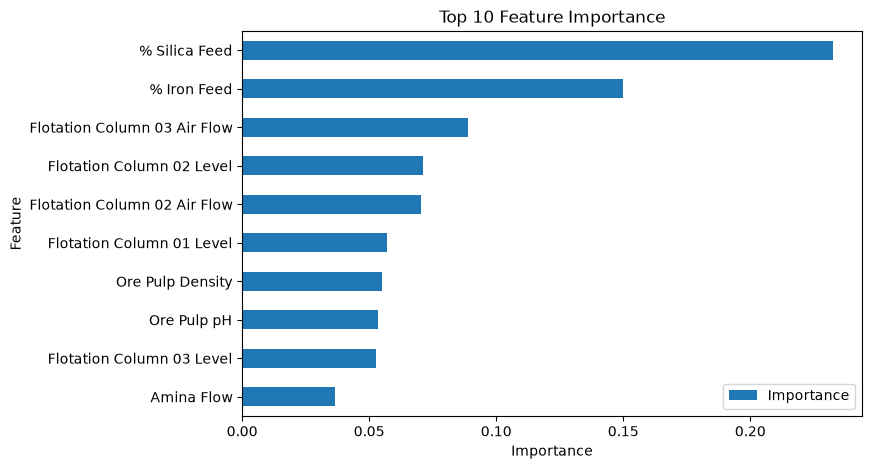

In [21]:
importance.head(10).plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(8,5)
)

plt.title("Top 10 Feature Importance")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

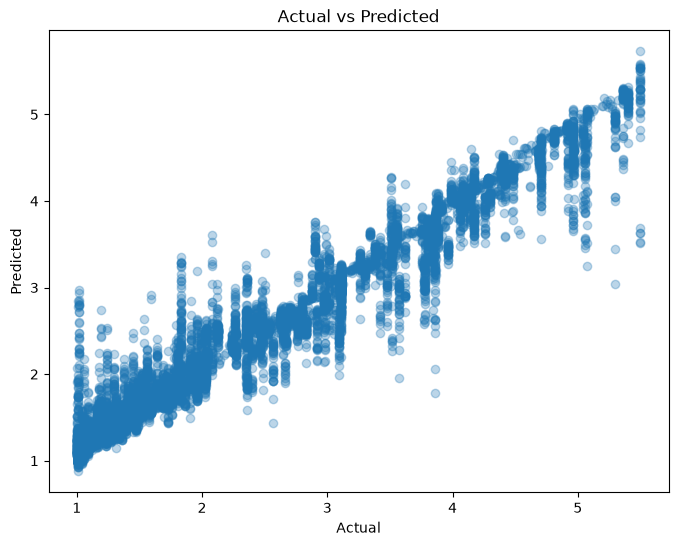

In [22]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.3
)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()

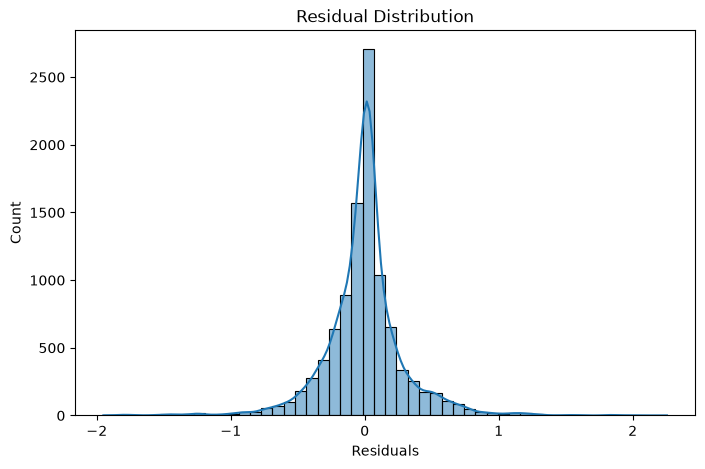

In [23]:
residuals = pd.Series(y_test.to_numpy() - y_pred, index=y_test.index, name="Residuals")

plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    bins=50,
    kde=True
)

plt.title("Residual Distribution")

plt.show()